## Surface+Land Evap and Land-Only Evap

### Read in ERA5 and create a surface +land evap arran and a land-only evap with zeros over ocean

### Read in ERA5 surface pressure (not from land)

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import scipy
import sys 
import warnings
import matplotlib.pyplot as plt
from shapely.geometry import mapping
import cartopy.crs as ccrs
import cartopy.feature
warnings.filterwarnings('ignore')
import time as timer
start_all = timer.time()

In [ ]:
dataf ="/Volumes/ESA_F4R/era/" 
datao ="/Volumes/ESA_F4R/ed_prepare/2026_mergeds/" 
datap ="/Users/ellendyer/Library/Mobile Documents/com~apple~CloudDocs/1SHARED_WORK/Work/3_ESA_GRANT/MODEL/plots/era/"

In [ ]:
#For selection and plotting
YR = 2010
time_bnds = (str(YR)+'-01-01',str(YR)+'-12-31')
lon_bnds, lat_bnds = (8, 32), (12,-15)
lon_bnds_f, lat_bnds_f = (8, 32), (-15,12) 
p_bnds = (30000,100000)

**Read in ERA5 surface vars for merging - setting non land evaporation to zero. Merging surface pressure level and land surface pressure to output.** 

In [4]:
start = timer.time()
from functools import partial
def _preprocess_land(x, lon_bnds, lat_bnds):
    x = x.sel(longitude=slice(*lon_bnds), latitude=slice(*lat_bnds),drop=True)
    return x
partial_func_land = partial(_preprocess_land, lon_bnds=lon_bnds, lat_bnds=lat_bnds)

#Reading in surface variables from ERA5 surface files
ds_era_psfc = xr.open_mfdataset(dataf+"era5/era5_surface/era5_surface_pressure_central_africa_"+str(YR)+"*.nc",
                                drop_variables=['expver','number'],
                                preprocess=partial_func_land,parallel=True).load()
ds_era_psfc = ds_era_psfc.rename({'valid_time':'time','latitude':'lat',
                                  'longitude':'lon','sp':'Psfc'})
Psfc_surface = ds_era_psfc['Psfc'].resample(time='MS').mean(dim='time')/100.0
ds_era_psfc.close()

ds_era_evap = xr.open_mfdataset(dataf+"era5/era5_surface/era5_evaporation_central_africa_"+str(YR)+"*.nc",
                                drop_variables=['expver','number'],
                                preprocess=partial_func_land,parallel=True).load()
ds_era_evap = ds_era_evap.rename({'valid_time':'time','latitude':'lat',
                                  'longitude':'lon','e':'Evap'})
Evap_surface = ds_era_evap.resample(time='D').sum(dim='time')*-1000.0
Evap_surface = Evap_surface.resample(time='MS').mean(dim='time')['Evap']
ds_era_evap.close()


end = timer.time()
length = end - start
print("ERA5 surface data read in took ", length, "seconds")

ERA5 surface data read in took  107.62071800231934 seconds


**Read in ERA5 land data (hourly in monthly files)**
- selecting hour 23 (0-23) of Prec and Evap because of how ERA5 Land variables are accumulated (https://confluence.ecmwf.int/pages/viewpage.action?pageId=197702790 - https://confluence.ecmwf.int/display/CKB/ERA5-Land%3A+data+documentation#ERA5Land:datadocumentation-accumulationsAccumulations)
- prec is multiplied by 1000 to convert from m to mm
- evap is multiplied by -1000 to convert from m to mm and upward fluxes in land model are considered negative
- Prec, Evap, and Psfc are then resampled to MS monthly and also interpolated to coarser pressure level grid

**Input file units:**
- tp - m (no longer need)
- e - m (-)
- sp - pa

In [5]:
start = timer.time()
from functools import partial
def _preprocess_land(x, lon_bnds, lat_bnds):
    x = x.sel(longitude=slice(*lon_bnds), latitude=slice(*lat_bnds),drop=True)
    return x
partial_func_land = partial(_preprocess_land, lon_bnds=lon_bnds, lat_bnds=lat_bnds)

#Reading in surface variables from ERA5 Land
ds_era_land = xr.open_mfdataset(dataf+"era5_land/era5_land_variables_central_africa_"+str(YR)+"*.nc",
                                drop_variables=['expver','number','pev','ssr','t2m','sp'],
                                preprocess=partial_func_land,parallel=True).load()
ds_era_land = ds_era_land.rename({'valid_time':'time','latitude':'lat',
                                  'longitude':'lon','tp':'Prec','e':'Evap'})
ds_era_land = ds_era_land.interp(lat=Evap_surface['lat'],lon=Evap_surface['lon'],method='linear',kwargs={"fill_value": "extrapolate"})
Prec = ds_era_land['Prec'].where(ds_era_land['time.hour']==23,drop=True)*1000.0
Evap_land = ds_era_land['Evap'].where(ds_era_land['time.hour']==23,drop=True)*-1000.0
Prec = Prec.resample(time='MS').mean(dim='time') 
Evap_land = Evap_land.resample(time='MS').mean(dim='time')
ds_era_land.close()

Evap_land_only = Evap_land
Evap_land = Evap_land.fillna(0.0)
Evap_all = Evap_land_only.combine_first(Evap_surface)

EvapL = xr.Dataset({"Evap_land":Evap_land})
EvapA = xr.Dataset({"Evap_all":Evap_all})

end = timer.time()
length = end - start
print("ERA5 land data read in took ", length, "seconds")

ERA5 land data read in took  604.0192959308624 seconds


## Plotting the different evaporation arrays

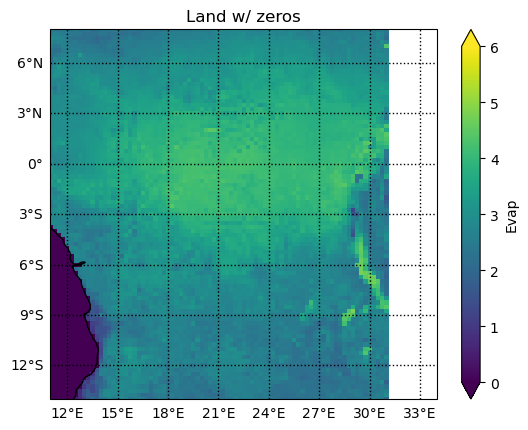

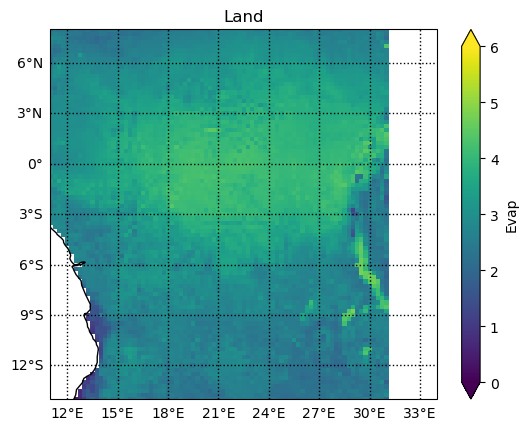

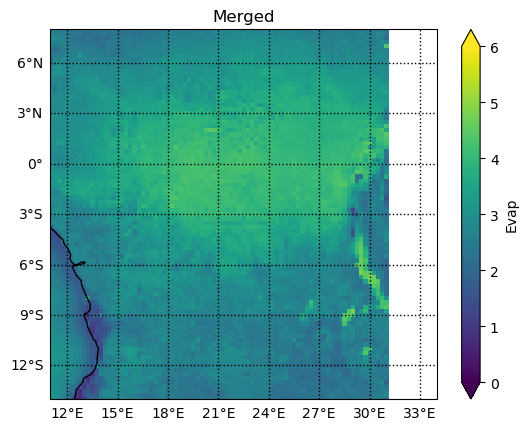

<Figure size 640x480 with 0 Axes>

In [6]:
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
#ax.add_feature(cartopy.feature.OCEAN)
Evap_land.mean('time').plot(ax=ax,transform=ccrs.PlateCarree(),
                                       add_colorbar=True,
                                       vmin=0,vmax=6,
                                       alpha=1,
                                       cmap=plt.cm.viridis,
                                       extend="both")
ax.set_extent([11, 34, -14, 8])
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='black', alpha=1, linestyle='dotted')
gl.top_labels = False
gl.right_labels = False
ax.set_title('Land w/ zeros')
#plt.savefig()
plt.show()
plt.clf()

ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
#ax.add_feature(cartopy.feature.OCEAN)
Evap_land_only.mean('time').plot(ax=ax,transform=ccrs.PlateCarree(),
                                       add_colorbar=True,
                                       vmin=0,vmax=6,
                                       alpha=1,
                                       cmap=plt.cm.viridis,
                                       extend="both")
ax.set_extent([11, 34, -14, 8])
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='black', alpha=1, linestyle='dotted')
gl.top_labels = False
gl.right_labels = False
ax.set_title('Land')
#plt.savefig()
plt.show()
plt.clf()

ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
#ax.add_feature(cartopy.feature.OCEAN)
Evap_all.mean('time').plot(ax=ax,transform=ccrs.PlateCarree(),
                                       add_colorbar=True,
                                       vmin=0,vmax=6,
                                       alpha=1,
                                       cmap=plt.cm.viridis,
                                       extend="both")
ax.set_extent([11, 34, -14, 8])
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='black', alpha=1, linestyle='dotted')
gl.top_labels = False
gl.right_labels = False
ax.set_title('Merged')
#plt.savefig()
plt.show()
plt.clf()


**Merging all input datasets into one dataset for recyling code called ds**
- close both input datasets
- sort everything so latitude is south to north
- transpose dimensions so they run (lon,lat,level,time) as in recycling code
- save input ds to file

In [8]:
start = timer.time()
ds = xr.merge([EvapL,EvapA,Psfc_surface]) 
ds = ds.sortby('lat', ascending=True)
ds = ds.sel(lat=slice(*lat_bnds_f),lon=slice(*lon_bnds_f))
ds = ds.transpose("lon", "lat", "level", "time",missing_dims='ignore')

ds.to_netcdf(datao+"merge_erads_S_LSE_"+str(YR)+".nc", mode='w', format='NETCDF4', engine='netcdf4')
end = timer.time()
length = end - start
print("Merging and dataset output took ", length, "seconds")

Merging and dataset output took  0.02391195297241211 seconds
